## Identificação De Anomalias Utilizando LSTM

# =============================================================================
# DETECÇÃO DE ANOMALIAS EM DADOS DE SENSORES INDUSTRIAIS (IIoT)
# =============================================================================
# Dataset: Industrial IoT Multi-Axis Vibration Dataset
# Fonte: Kaggle (sydsxdiq)
# Link: https://www.kaggle.com/datasets/sydsxdiq/industrial-iot-dataset-vibration-gas-environment



In [29]:
# Instalar pacotes necessários (se ainda não estiverem instalados)
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn tensorflow -q

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from scipy import stats
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Verificar versão do TensorFlow
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [5]:
# Download do dataset usando kagglehub
print("Baixando dataset...")
path = kagglehub.dataset_download("sydsxdiq/industrial-iot-dataset-vibration-gas-environment")
print("Arquivos baixados em:", path)
print("Conteúdo do diretório:")
os.listdir(path)


Baixando dataset...


100%|██████████| 1.99M/1.99M [00:00<00:00, 146MB/s]

Extracting files...
Arquivos baixados em: /root/.cache/kagglehub/datasets/sydsxdiq/industrial-iot-dataset-vibration-gas-environment/versions/1
Conteúdo do diretório:


['Industrial_IOT_Dataset.csv']

In [6]:
# Listar arquivos CSV (assumindo que existem vários)
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("Arquivos CSV encontrados:", csv_files)

# Vamos escolher um dos arquivos para análise.
# Normalmente esses datasets têm múltiplos sensores.
# Vamos carregar o primeiro (ou você pode escolher um específico).
file_path = os.path.join(path, csv_files[0])
print(f"Carregando arquivo: {file_path}")

df_raw = pd.read_csv(file_path)

# Visualizar primeiras linhas e estrutura
print("\nPrimeiras linhas:")
print(df_raw.head())
print("\nInformações:")
print(df_raw.info())

Arquivos CSV encontrados: ['Industrial_IOT_Dataset.csv']
Carregando arquivo: /root/.cache/kagglehub/datasets/sydsxdiq/industrial-iot-dataset-vibration-gas-environment/versions/1/Industrial_IOT_Dataset.csv

Primeiras linhas:
       timestamp_index  ambient_temp_c  process_temp_c  ambient_humidity_pct  \
0  2025-01-01 00:00:00       25.241785       30.304961             49.572042   
1  2025-01-01 00:01:00       23.654339       30.186344             52.556004   
2  2025-01-01 00:02:00       25.619221       24.817427             50.220952   
3  2025-01-01 00:03:00       27.807575       30.679639             55.883344   
4  2025-01-01 00:04:00       23.414617       34.931316             64.577428   

   pressure_kpa  airflow_rate_m3h  fan_speed_rpm  exhaust_damper_pct  \
0    101.084865        527.862900    1225.631029           78.230803   
1    101.251016        522.665887    1201.838315           81.715063   
2    101.396442        425.078412    1135.326740           50.327530   
3    10

Pré Processamento

In [7]:
# -----------------------------------------------------------------------------
# 2. PRÉ-PROCESSAMENTO E SELEÇÃO DA SÉRIE TEMPORAL
# -----------------------------------------------------------------------------
# Vamos supor que a primeira coluna seja timestamp e a segunda seja a leitura do sensor.
# Ajuste os nomes conforme necessário.

# Se houver coluna 'timestamp' ou similar, converter para datetime
timestamp_col = None
for col in df_raw.columns:
    if 'time' in col.lower() or 'date' in col.lower() or 'timestamp' in col.lower():
        timestamp_col = col
        break

if timestamp_col:
    df_raw[timestamp_col] = pd.to_datetime(df_raw[timestamp_col])
    df = df_raw.sort_values(timestamp_col).reset_index(drop=True)
    time_axis = df[timestamp_col]
else:
    # Se não houver timestamp, usar índice como eixo
    df = df_raw.copy()
    time_axis = df.index

# Selecionar uma coluna numérica para análise (a primeira coluna numérica após timestamp, se existir)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if timestamp_col and timestamp_col in numeric_cols:
    numeric_cols.remove(timestamp_col)  # remover timestamp se for numérico (ex.: Unix time)

if len(numeric_cols) == 0:
    raise ValueError("Nenhuma coluna numérica encontrada para análise.")

# Escolher a primeira coluna numérica (ou você pode escolher uma específica)
sensor_col = numeric_cols[0]
print(f"Coluna selecionada para análise: {sensor_col}")

# Extrair a série temporal
values = df[sensor_col].values.reshape(-1, 1)

# Se houver uma coluna de rótulo de anomalia (ex.: 'label', 'anomaly'), capturar
label_col = None
for col in df.columns:
    if 'label' in col.lower() or 'anomaly' in col.lower() or 'class' in col.lower():
        label_col = col
        break

if label_col:
    print(f"Coluna de rótulo encontrada: {label_col}")
    y_true = df[label_col].values
else:
    y_true = None
    print("Nenhum rótulo de anomalia encontrado. A avaliação será apenas visual.")

# Criar DataFrame final com data/hora e valor
df_series = pd.DataFrame({
    'time': time_axis if timestamp_col else np.arange(len(df)),
    'value': values.flatten()
})

# Remover valores ausentes
df_series = df_series.dropna().reset_index(drop=True)
values = df_series['value'].values.reshape(-1, 1)

print(f"Série temporal final: {len(df_series)} pontos")
print(df_series.head())

Coluna selecionada para análise: ambient_temp_c
Nenhum rótulo de anomalia encontrado. A avaliação será apenas visual.
Série temporal final: 5000 pontos
                 time      value
0 2025-01-01 00:00:00  25.241785
1 2025-01-01 00:01:00  23.654339
2 2025-01-01 00:02:00  25.619221
3 2025-01-01 00:03:00  27.807575
4 2025-01-01 00:04:00  23.414617


Detecção Básica de Anomalias


--- Estatísticas Descritivas ---
count    5000.000000
mean       24.014005
std         2.491200
min        15.896832
25%        22.355237
50%        24.033664
75%        25.665027
max        33.815594
Name: value, dtype: float64


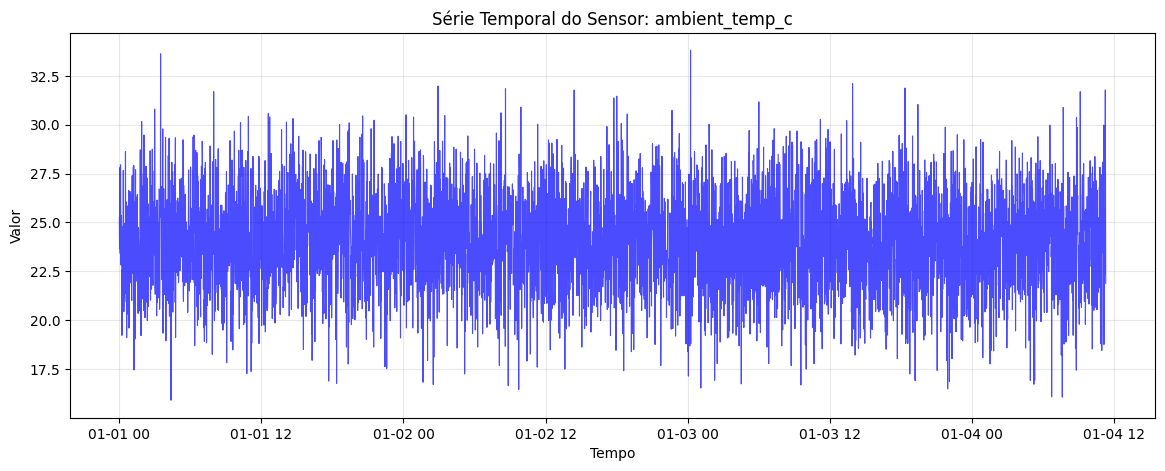

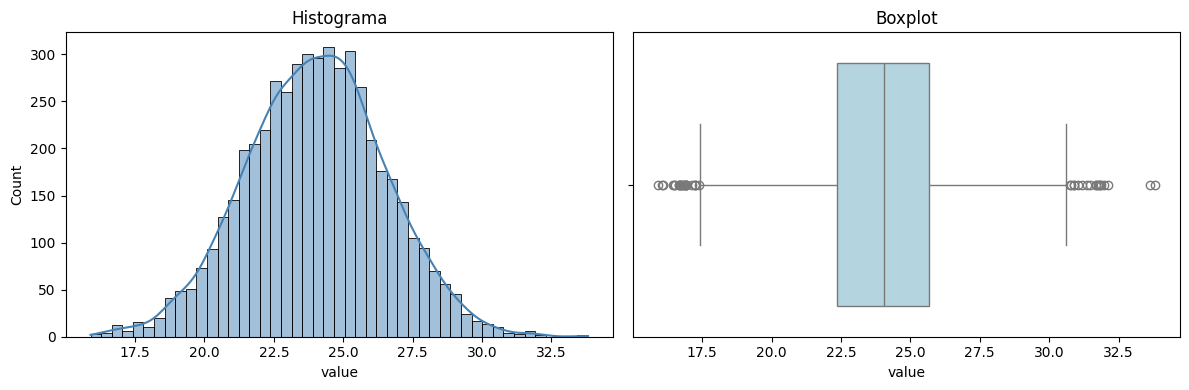

Z-Score (3σ): 16 anomalias
IQR: 42 anomalias
Média Móvel: 6 anomalias


In [8]:
# -----------------------------------------------------------------------------
# 3. ANÁLISE ESTATÍSTICA BÁSICA E DETECÇÃO CLÁSSICA
# -----------------------------------------------------------------------------
print("\n--- Estatísticas Descritivas ---")
print(df_series['value'].describe())

# Visualização da série temporal
plt.figure(figsize=(14,5))
plt.plot(df_series['time'], df_series['value'], color='blue', alpha=0.7, linewidth=0.8)
plt.title(f'Série Temporal do Sensor: {sensor_col}')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.show()

# Histograma e boxplot
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df_series['value'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Histograma')
sns.boxplot(x=df_series['value'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot')
plt.tight_layout()
plt.show()

# --- Métodos clássicos ---
from scipy import stats

# Z-Score
z_scores = np.abs(stats.zscore(df_series['value']))
df_series['anomaly_z'] = z_scores > 3
print(f"Z-Score (3σ): {df_series['anomaly_z'].sum()} anomalias")

# IQR
Q1 = df_series['value'].quantile(0.25)
Q3 = df_series['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_series['anomaly_iqr'] = (df_series['value'] < lower_bound) | (df_series['value'] > upper_bound)
print(f"IQR: {df_series['anomaly_iqr'].sum()} anomalias")

# Média Móvel + 3σ (janela de 50 pontos, ajustável)
window_roll = 50
df_series['roll_mean'] = df_series['value'].rolling(window_roll, center=True, min_periods=window_roll//2).mean()
df_series['roll_std'] = df_series['value'].rolling(window_roll, center=True, min_periods=window_roll//2).std()
df_series['roll_upper'] = df_series['roll_mean'] + 3 * df_series['roll_std']
df_series['roll_lower'] = df_series['roll_mean'] - 3 * df_series['roll_std']
df_series['anomaly_roll'] = (df_series['value'] < df_series['roll_lower']) | (df_series['value'] > df_series['roll_upper'])
print(f"Média Móvel: {df_series['anomaly_roll'].sum()} anomalias")

LSTM - AUTOENCODER

In [18]:
# -----------------------------------------------------------------------------
# 4. PREPARAÇÃO DOS DADOS PARA O LSTM AUTOENCODER
# -----------------------------------------------------------------------------
# Parâmetros do LSTM
WINDOW = 60          # tamanho da janela (ajustável)
USE_ROBUST_SCALER = True  # True para RobustScaler (recomendado para dados com outliers)

if USE_ROBUST_SCALER:
    scaler = RobustScaler()
else:
    scaler = StandardScaler()

values_scaled = scaler.fit_transform(values)

def create_sequences(data, window_size):
    X = []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
    return np.array(X)

X = create_sequences(values_scaled, WINDOW)
print(f"Shape dos dados sequenciais: {X.shape}")

# Divisão treino/teste (80/20, mantendo ordem temporal)
train_size = int(0.8 * len(X))
X_train = X[:train_size]
X_test = X[train_size:]

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Shape dos dados sequenciais: (4940, 60, 1)
Treino: 3952 amostras
Teste: 988 amostras


In [19]:
# -----------------------------------------------------------------------------
# 5. CONSTRUÇÃO DO AUTOENCODER LSTM
# -----------------------------------------------------------------------------
model = keras.Sequential([
    layers.Input(shape=(WINDOW, 1)),

    # Encoder
    layers.LSTM(128, return_sequences=True, dropout=0.2),
    layers.LSTM(64, return_sequences=False, dropout=0.2),

    # Bottleneck -> Decoder
    layers.RepeatVector(WINDOW),
    layers.LSTM(64, return_sequences=True, dropout=0.2),
    layers.LSTM(128, return_sequences=True, dropout=0.2),

    # Output
    layers.TimeDistributed(layers.Dense(1))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 60, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 60, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,937 (968.50 KB)

 Trainable params: 247,937 (968.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - loss: 0.5497 - val_loss: 0.5277
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.5480 - val_loss: 0.5334
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.5483 - val_loss: 0.5290
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.5463 - val_loss: 0.5231
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.5457 - val_loss: 0.5237
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.5454 - val_loss: 0.5252
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.5463 - val_loss: 0.5204
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.5446 - val_loss: 0.5223
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.5460 - val_loss: 0.5199
Epoch 10/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.5438 - val_loss: 0.5182
Epoch 11/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.5398 - val_loss: 0.5184
Epoch 12/100
112/112 ━━━━━━━━

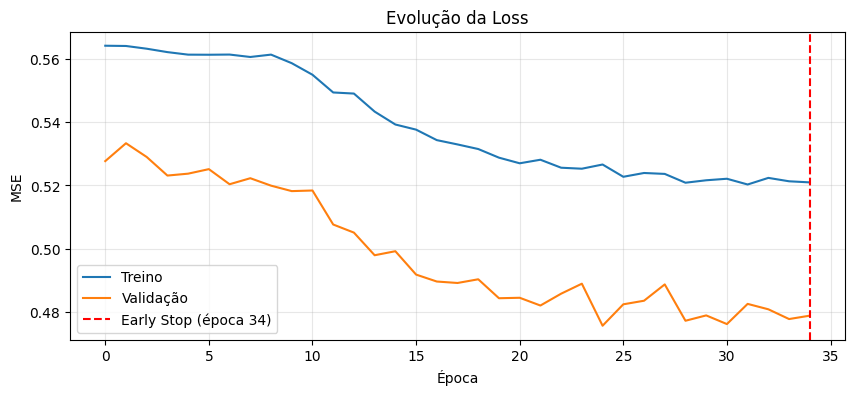

In [11]:
# -----------------------------------------------------------------------------
# 6. TREINAMENTO
# -----------------------------------------------------------------------------
history = model.fit(
    X_train, X_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

# Plot da loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
if early_stop.stopped_epoch > 0:
    plt.axvline(x=early_stop.stopped_epoch, color='red', linestyle='--',
                label=f'Early Stop (época {early_stop.stopped_epoch})')
plt.title('Evolução da Loss')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# -----------------------------------------------------------------------------
# 7. DETECÇÃO DE ANOMALIAS COM O AUTOENCODER
# -----------------------------------------------------------------------------
X_pred = model.predict(X, verbose=0)
mse = np.mean(np.square(X - X_pred), axis=(1, 2))

# Definição do limiar (percentil 99% do erro no treino)
threshold = np.percentile(mse[:train_size], 99)
print(f"Limiar (percentil 99% do treino): {threshold:.6f}")

anomaly_idx = np.where(mse > threshold)[0]
print(f"Total de sequências anômalas: {len(anomaly_idx)}")

# Mapear para as datas (usando centro da janela)
center = WINDOW // 2
anomaly_dates_indices = center + anomaly_idx
anomaly_dates_indices = anomaly_dates_indices[anomaly_dates_indices < len(df_series)]

df_series['anomaly_lstm'] = False
df_series.loc[df_series.index[anomaly_dates_indices], 'anomaly_lstm'] = True
print(f"Anomalias LSTM detectadas: {df_series['anomaly_lstm'].sum()}")

Limiar (percentil 99% do treino): 0.716953
Total de sequências anômalas: 68
Anomalias LSTM detectadas: 68


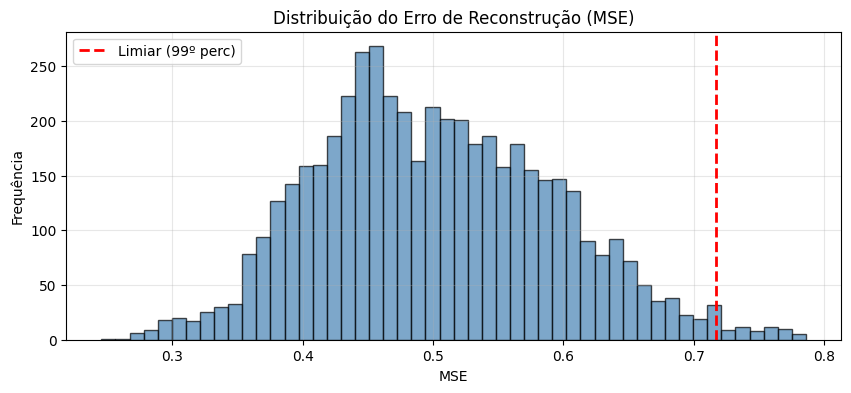

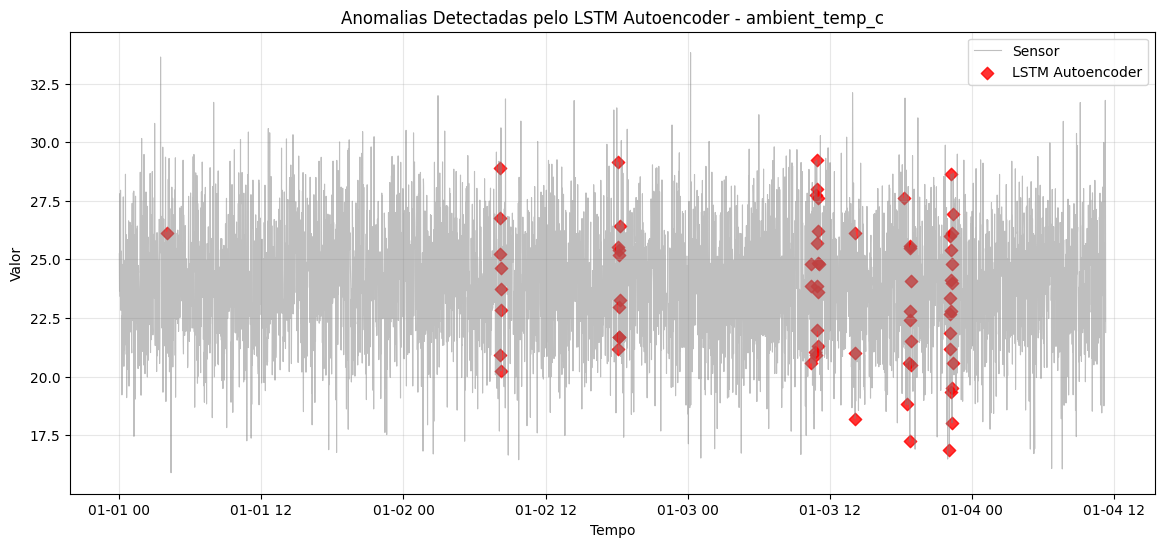

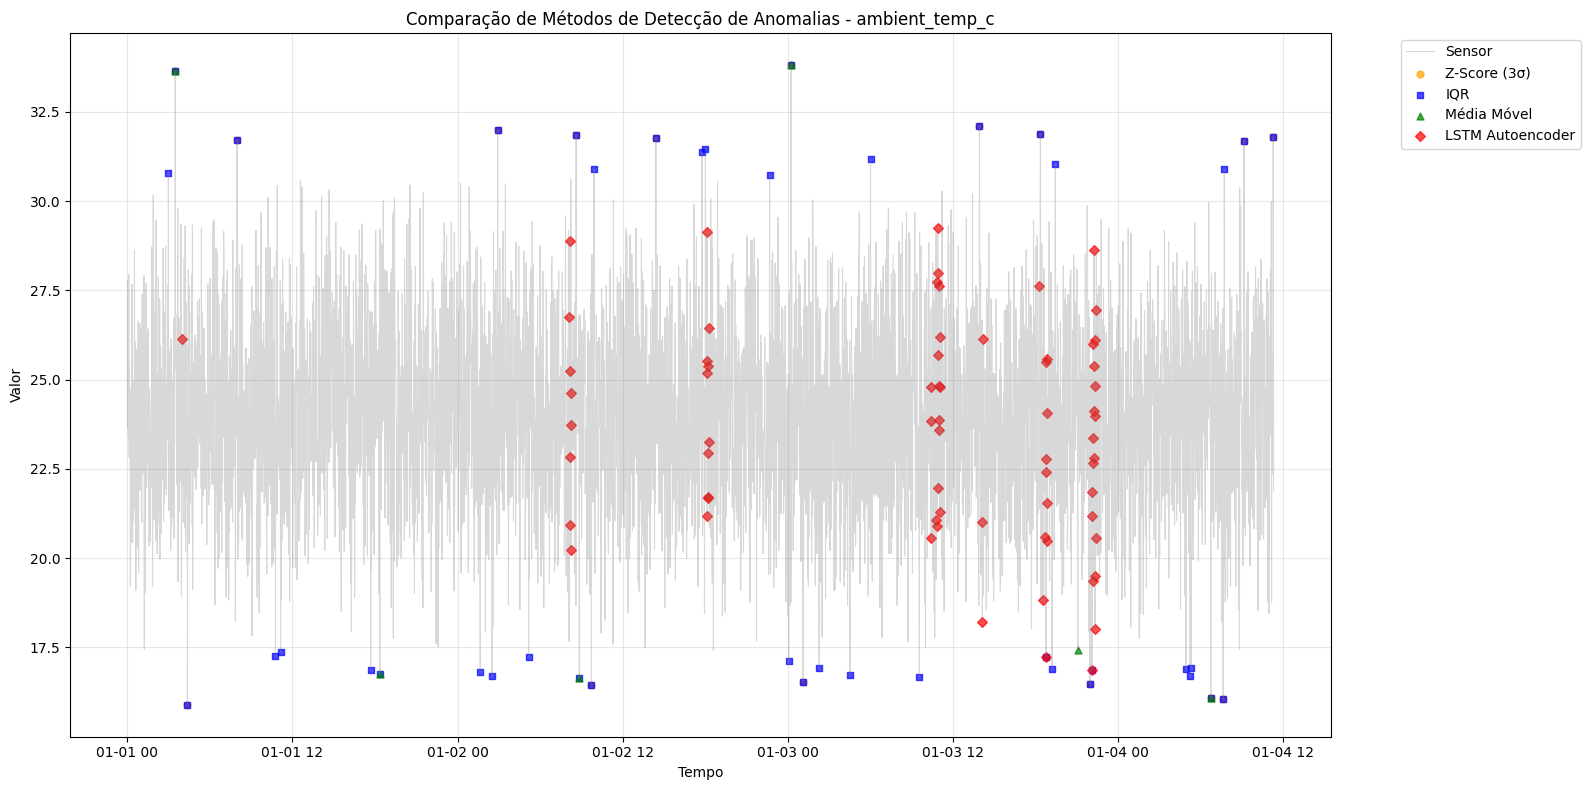


--- Comparação de Métodos ---
anomaly_z: 16 anomalias (0.32%)
anomaly_iqr: 42 anomalias (0.84%)
anomaly_roll: 6 anomalias (0.12%)
anomaly_lstm: 68 anomalias (1.36%)


In [13]:
# -----------------------------------------------------------------------------
# 8. VISUALIZAÇÃO DOS RESULTADOS
# -----------------------------------------------------------------------------
# Distribuição do erro
plt.figure(figsize=(10,4))
plt.hist(mse, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Limiar (99º perc)')
plt.title('Distribuição do Erro de Reconstrução (MSE)')
plt.xlabel('MSE')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Série temporal com anomalias do LSTM
plt.figure(figsize=(14,6))
plt.plot(df_series['time'], df_series['value'], color='gray', alpha=0.5, linewidth=0.8, label='Sensor')
plt.scatter(df_series[df_series['anomaly_lstm']]['time'], df_series[df_series['anomaly_lstm']]['value'],
            color='red', s=40, marker='D', label='LSTM Autoencoder', alpha=0.8)
plt.title(f'Anomalias Detectadas pelo LSTM Autoencoder - {sensor_col}')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comparação de todos os métodos
plt.figure(figsize=(16,8))
plt.plot(df_series['time'], df_series['value'], color='gray', alpha=0.3, linewidth=0.8, label='Sensor')

metodos = {
    'anomaly_z': {'cor': 'orange', 'marker': 'o', 'label': 'Z-Score (3σ)'},
    'anomaly_iqr': {'cor': 'blue', 'marker': 's', 'label': 'IQR'},
    'anomaly_roll': {'cor': 'green', 'marker': '^', 'label': 'Média Móvel'},
    'anomaly_lstm': {'cor': 'red', 'marker': 'D', 'label': 'LSTM Autoencoder'}
}

for metodo, props in metodos.items():
    dados = df_series[df_series[metodo]]
    plt.scatter(dados['time'], dados['value'],
                color=props['cor'], marker=props['marker'],
                s=25, alpha=0.7, label=props['label'])

plt.title(f'Comparação de Métodos de Detecção de Anomalias - {sensor_col}')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estatísticas comparativas
print("\n--- Comparação de Métodos ---")
for metodo in metodos.keys():
    count = df_series[metodo].sum()
    pct = count / len(df_series) * 100
    print(f"{metodo}: {count} anomalias ({pct:.2f}%)")

In [1]:
# -----------------------------------------------------------------------------
# 10. SUGESTÕES DE AJUSTES
# -----------------------------------------------------------------------------
print("""
=== SUGESTÕES PARA MELHORAR O LSTM ===
1. Ajuste WINDOW (tamanho da janela) para capturar melhor os padrões.
2. Altere a arquitetura: mais unidades, dropout, camadas Conv1D.
3. Experimente limiares adaptativos (ex.: média móvel do erro).
4. Use RobustScaler se houver outliers extremos.
5. Se houver rótulos, otimize o threshold para maximizar F1-score.
6. Inclua outras features (outros sensores) para melhorar a detecção.
""")


=== SUGESTÕES PARA MELHORAR O LSTM ===
1. Ajuste WINDOW (tamanho da janela) para capturar melhor os padrões.
2. Altere a arquitetura: mais unidades, dropout, camadas Conv1D.
3. Experimente limiares adaptativos (ex.: média móvel do erro).
4. Use RobustScaler se houver outliers extremos.
5. Se houver rótulos, otimize o threshold para maximizar F1-score.
6. Inclua outras features (outros sensores) para melhorar a detecção.

